In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLIENTS  = 10
NUM_ROUNDS   = 20
LOCAL_EPOCHS = 3
BATCH_SIZE   = 32
LR           = 0.01

MALICIOUS_CLIENTS = [0, 1, 2]
SOURCE_CLASS      = 1
TARGET_CLASS      = 7
POISON_RATIO      = 1.0

STEALTH_START = 2.0
STEALTH_END   = 0.2
BOOST_START   = 2.0
BOOST_END     = 4.5

Using device: cpu


In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train size:", len(train_dataset))
print("Test size:",  len(test_dataset))

Train size: 60000
Test size: 10000


In [4]:
all_indices = np.arange(len(train_dataset))
np.random.shuffle(all_indices)
client_indices = np.array_split(all_indices, NUM_CLIENTS)

for i, idxs in enumerate(client_indices):
    print(f"Client {i}: {len(idxs)} samples")

Client 0: 6000 samples
Client 1: 6000 samples
Client 2: 6000 samples
Client 3: 6000 samples
Client 4: 6000 samples
Client 5: 6000 samples
Client 6: 6000 samples
Client 7: 6000 samples
Client 8: 6000 samples
Client 9: 6000 samples


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

global_model = SimpleCNN().to(device)
print(global_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
class PoisonedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, malicious=False,
                 source_class=1, target_class=7, poison_ratio=1.0):
        self.dataset = dataset
        self.indices = list(indices)
        self.malicious = malicious
        self.source_class = source_class
        self.target_class = target_class

        self.poisoned_positions = set()
        if self.malicious:
            source_positions = [
                pos for pos, idx in enumerate(self.indices)
                if int(self.dataset[idx][1]) == self.source_class
            ]
            n_poison = int(len(source_positions) * poison_ratio)
            self.poisoned_positions = set(source_positions[:n_poison])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x, y = self.dataset[idx]
        y = int(y)
        if self.malicious and i in self.poisoned_positions:
            y = self.target_class
        return x, y

In [7]:
def train_local(model, dataset, epochs=1, batch_size=32, lr=0.01):
    model.train()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model.state_dict()


def malicious_train_pgd(global_state, poisoned_dataset,
                        epochs, batch_size, lr, stealth_weight):
    model = SimpleCNN().to(device)
    model.load_state_dict(global_state)
    model.train()

    loader    = DataLoader(poisoned_dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    global_params = {
        k: v.clone().detach().float()
        for k, v in global_state.items()
        if v.dtype in (torch.float32, torch.float64)
    }

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            task_loss = criterion(model(x), y)

            stealth_loss = 0.0
            for name, param in model.named_parameters():
                if name in global_params:
                    stealth_loss = stealth_loss + ((param - global_params[name]) ** 2).sum()

            total_loss = task_loss + stealth_weight * stealth_loss
            total_loss.backward()
            optimizer.step()

    return model.state_dict()

In [8]:
def fedavg(state_dicts):
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state.keys():
        for i in range(1, len(state_dicts)):
            avg_state[key] += state_dicts[i][key]
        avg_state[key] = avg_state[key] / len(state_dicts)
    return avg_state

In [9]:
def evaluate_mta_asr(model, test_dataset,
                     source_class=1, target_class=7, batch_size=256):
    model.eval()
    loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0
    source_total = 0
    source_to_target = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            mask = (y == source_class)
            source_total += mask.sum().item()
            source_to_target += ((preds == target_class) & mask).sum().item()

    mta = correct / total
    asr = source_to_target / source_total if source_total > 0 else 0.0

    return mta, asr

In [10]:
mta_history = []
asr_history = []

for rnd in range(NUM_ROUNDS):
    local_states = []

    progress       = rnd / (NUM_ROUNDS - 1)
    stealth_weight = STEALTH_START + (STEALTH_END - STEALTH_START) * progress
    boost_factor   = BOOST_START   + (BOOST_END   - BOOST_START)   * progress

    for client_id in range(NUM_CLIENTS):
        is_malicious = client_id in MALICIOUS_CLIENTS

        if is_malicious:
            poisoned_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = True,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = POISON_RATIO
            )

            local_state = malicious_train_pgd(
                global_state     = global_model.state_dict(),
                poisoned_dataset = poisoned_dataset,
                epochs           = LOCAL_EPOCHS,
                batch_size       = BATCH_SIZE,
                lr               = LR,
                stealth_weight   = stealth_weight
            )

            global_state = global_model.state_dict()
            for key in local_state.keys():
                delta            = local_state[key].float() - global_state[key].float()
                local_state[key] = global_state[key] + boost_factor * delta

        else:
            local_model = SimpleCNN().to(device)
            local_model.load_state_dict(global_model.state_dict())

            honest_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = False,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = 0.0
            )
            local_state = train_local(
                model      = local_model,
                dataset    = honest_dataset,
                epochs     = LOCAL_EPOCHS,
                batch_size = BATCH_SIZE,
                lr         = LR
            )

        local_states.append(local_state)

    new_global_state = fedavg(local_states)
    global_model.load_state_dict(new_global_state)

    mta, asr = evaluate_mta_asr(
        model        = global_model,
        test_dataset = test_dataset,
        source_class = SOURCE_CLASS,
        target_class = TARGET_CLASS
    )

    mta_history.append(mta)
    asr_history.append(asr)
    print(f"Round {rnd+1:02d} | stealth={stealth_weight:.2f} | boost={boost_factor:.2f} | MTA: {mta:.4f} | ASR: {asr:.4f}")

Round 01 | stealth=2.00 | boost=2.00 | MTA: 0.7891 | ASR: 0.0009
Round 02 | stealth=1.91 | boost=2.13 | MTA: 0.8787 | ASR: 0.0044
Round 03 | stealth=1.81 | boost=2.26 | MTA: 0.8855 | ASR: 0.1189
Round 04 | stealth=1.72 | boost=2.39 | MTA: 0.9193 | ASR: 0.0194
Round 05 | stealth=1.62 | boost=2.53 | MTA: 0.9105 | ASR: 0.2026
Round 06 | stealth=1.53 | boost=2.66 | MTA: 0.9347 | ASR: 0.0705
Round 07 | stealth=1.43 | boost=2.79 | MTA: 0.8992 | ASR: 0.4194
Round 08 | stealth=1.34 | boost=2.92 | MTA: 0.9455 | ASR: 0.0899
Round 09 | stealth=1.24 | boost=3.05 | MTA: 0.8999 | ASR: 0.5260
Round 10 | stealth=1.15 | boost=3.18 | MTA: 0.9347 | ASR: 0.1577
Round 11 | stealth=1.05 | boost=3.32 | MTA: 0.9254 | ASR: 0.3084
Round 12 | stealth=0.96 | boost=3.45 | MTA: 0.9157 | ASR: 0.4643
Round 13 | stealth=0.86 | boost=3.58 | MTA: 0.9088 | ASR: 0.5278
Round 14 | stealth=0.77 | boost=3.71 | MTA: 0.8978 | ASR: 0.6018
Round 15 | stealth=0.67 | boost=3.84 | MTA: 0.8886 | ASR: 0.7110
Round 16 | stealth=0.58 |

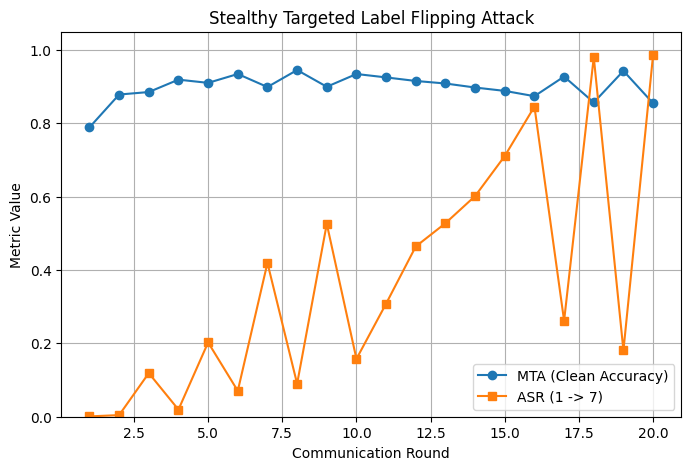

Final MTA: 0.8549
Final ASR: 0.986784140969163


In [11]:
rounds = np.arange(1, NUM_ROUNDS + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, mta_history, marker='o', label='MTA (Clean Accuracy)')
plt.plot(rounds, asr_history, marker='s', label='ASR (1 -> 7)')
plt.xlabel("Communication Round")
plt.ylabel("Metric Value")
plt.title("Stealthy Targeted Label Flipping Attack")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

print("Final MTA:", mta_history[-1])
print("Final ASR:", asr_history[-1])